# Diabetes Risk — EDA & Data Cleaning

**Projet :** Clustering + classification du risque de diabète à partir de constantes cliniques (Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, Age).

**Ce notebook couvre (Épic SP-1) :**
1. Chargement et inspection du dataset
2. Détection des valeurs manquantes et doublons
3. Analyse de la distribution des variables numériques
4. Détection et traitement des outliers
5. Étude des corrélations (pairplot)
6. Normalisation / standardisation des variables


## 1. Imports & chemins

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

ROOT_PATH = Path.cwd().parent
RAW_DATA_PATH = ROOT_PATH / "data" / "raw"
PROCESSED_DATA_PATH = ROOT_PATH / "data" / "processed"
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)


## 2. Chargement des données

In [2]:
df = pd.read_csv(RAW_DATA_PATH / "data.csv")

# La colonne "Unnamed: 0" est un index résiduel de l'export CSV -> on la supprime,
# ce n'est pas une variable clinique.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [3]:
print("Dimensions :", df.shape)
df.info()


Dimensions : (768, 8)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


## 3. Valeurs manquantes et doublons

Le dataset n'a pas de `NaN` explicites, mais certaines colonnes cliniques
utilisent **0 comme valeur impossible / placeholder de valeur manquante**
(ex. une pression artérielle de 0 n'est pas physiologiquement possible).
On vérifie d'abord les NaN "classiques" et les doublons, puis on quantifiera
les zéros suspects juste après.

In [5]:
print("Doublons :", df.duplicated().sum())
print("\nValeurs manquantes (NaN) par colonne :\n", df.isna().sum())


Doublons : 0

Valeurs manquantes (NaN) par colonne :
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [6]:
# Colonnes où un 0 est physiologiquement impossible / suspect
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = {c: int((df[c] == 0).sum()) for c in zero_check_cols}
zero_pct = {c: round(v / len(df) * 100, 1) for c, v in zero_counts.items()}

pd.DataFrame({"n_zeros": zero_counts, "pct": zero_pct})


,n_zeros,pct
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


**Constat :** `Insulin` et `SkinThickness` ont un taux de zéros trop élevé
pour justifier une suppression de lignes (on perdrait une part importante des
768 observations). On traite ces zéros comme des valeurs manquantes et on les
impute (voir section 6), plutôt que de dropper des lignes.

## 4. Distribution des variables numériques

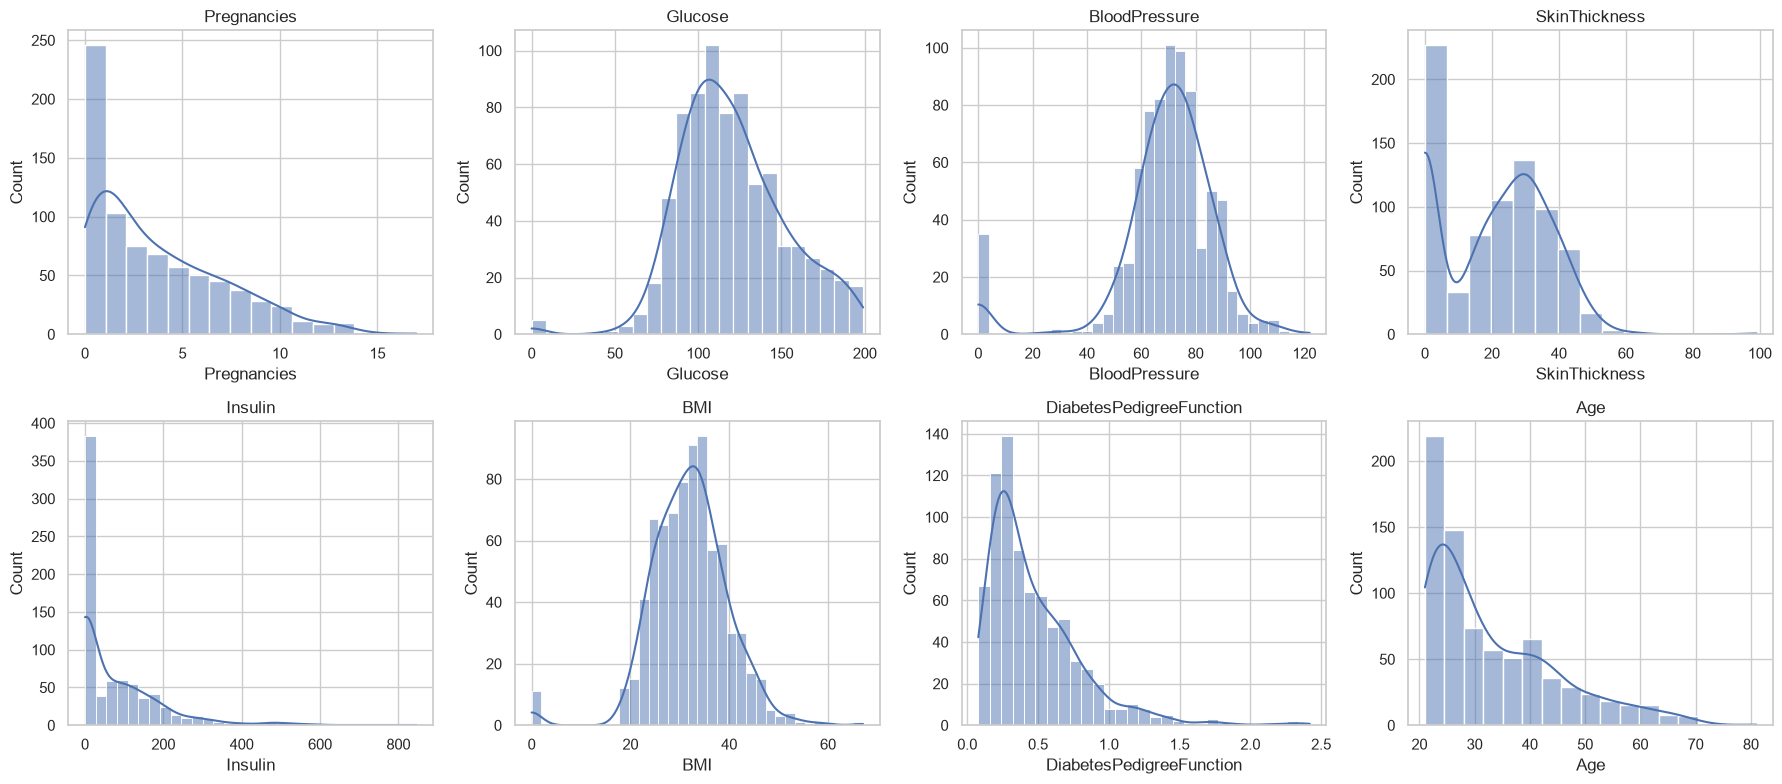

In [7]:
num_cols = df.columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


## 5. Détection des outliers (boxplots)

On visualise chaque variable avec un boxplot. Les points au-delà des
moustaches sont des outliers selon la règle IQR (1.5 * IQR).

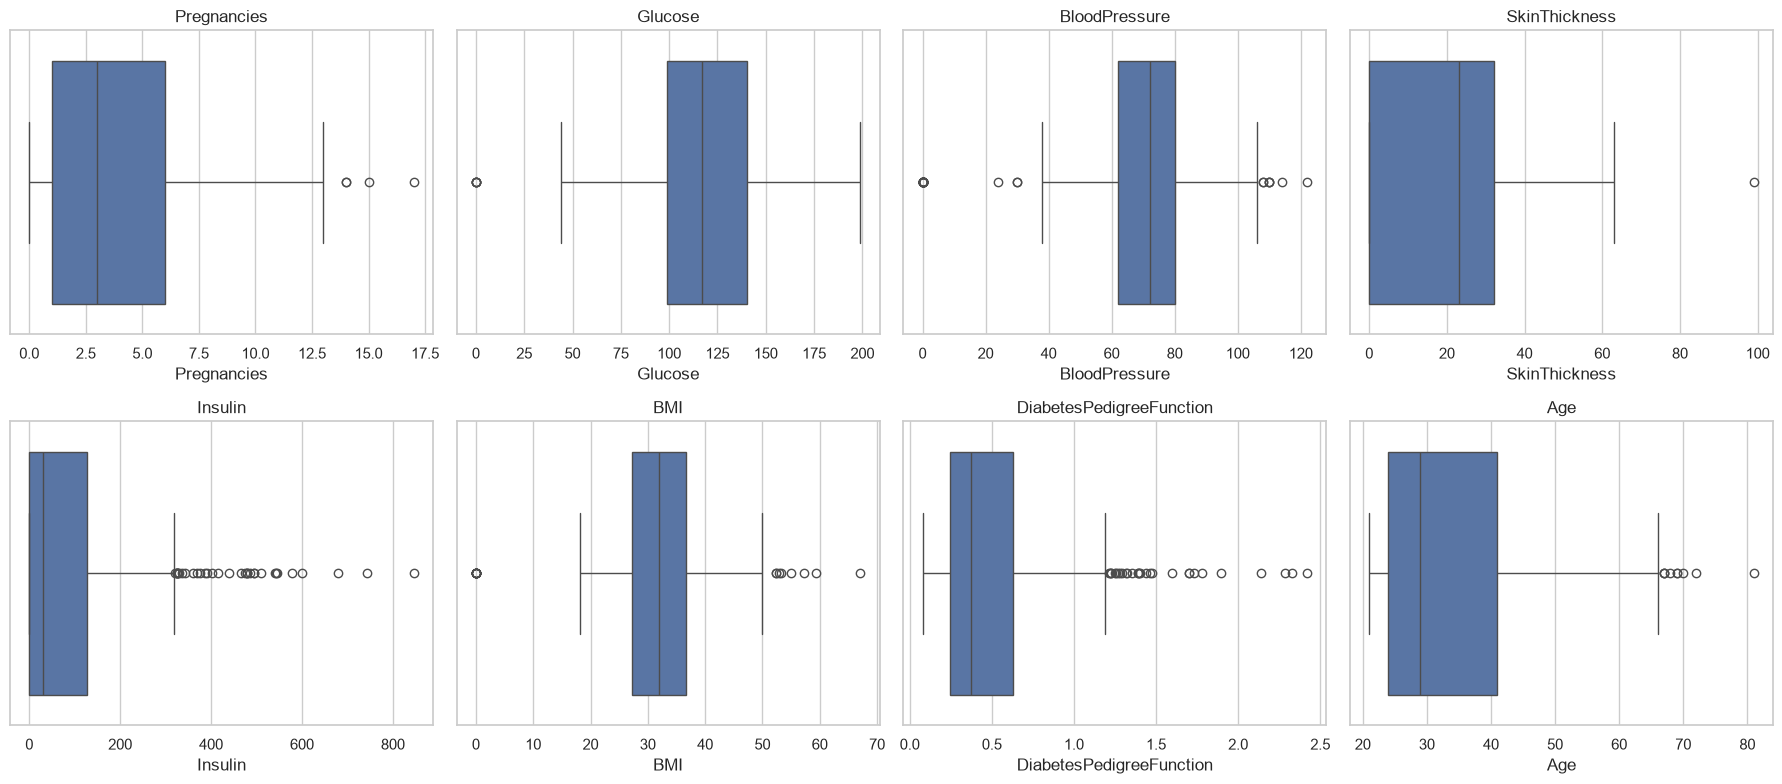

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [9]:
def iqr_outlier_report(df, cols):
    report = {}
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[col] < low) | (df[col] > high)).sum()
        report[col] = {"low_bound": round(low, 2), "high_bound": round(high, 2), "n_outliers": int(n_out)}
    return pd.DataFrame(report).T

iqr_outlier_report(df, num_cols)


,low_bound,high_bound,n_outliers
Pregnancies,-6.50,13.50,4.0
Glucose,37.12,202.12,5.0
BloodPressure,35.00,107.00,45.0
SkinThickness,-48.00,80.00,1.0
Insulin,-190.88,318.12,34.0
BMI,13.35,50.55,19.0
DiabetesPedigreeFunction,-0.33,1.20,29.0
Age,-1.50,66.50,9.0


**Décision :** on ne supprime pas de lignes pour les outliers ici.
- Les zéros dans `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`
  sont traités comme des valeurs manquantes (imputation, section 6), pas comme
  des outliers à retirer.
- Les valeurs hautes réelles (ex. `Insulin` élevé, `DiabetesPedigreeFunction` > 1,
  `Age` > 65) restent des observations cliniquement plausibles : les garder
  évite de biaiser les clusters à haut risque, qui sont justement ces profils
  extrêmes.

## 6. Traitement des valeurs manquantes (0 → NaN → imputation KNN)

In [10]:
nan_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[nan_columns] = df[nan_columns].replace(0, np.nan)

df.isna().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

On utilise `KNNImputer` : la valeur manquante d'une ligne est estimée à
partir des `k` observations les plus proches (sur les autres variables non
manquantes), plutôt qu'une simple médiane globale — ce qui respecte mieux les
corrélations entre variables (ex. BMI / Insulin / SkinThickness).

On compare deux variantes (`uniform` vs `distance`) avant de choisir.

In [11]:
imputer_uniform = KNNImputer(n_neighbors=5, weights="uniform", metric="nan_euclidean")
imputer_distance = KNNImputer(n_neighbors=5, weights="distance", metric="nan_euclidean")

df_uniform = pd.DataFrame(imputer_uniform.fit_transform(df), columns=df.columns)
df_distance = pd.DataFrame(imputer_distance.fit_transform(df), columns=df.columns)

diff = (df_uniform[nan_columns].mean() - df_distance[nan_columns].mean()).round(3)
print("Différence moyenne (uniform - distance) :\n", diff)


Différence moyenne (uniform - distance) :
 Glucose          0.007
BloodPressure   -0.008
SkinThickness   -0.007
Insulin         -0.309
BMI             -0.005
dtype: float64


In [12]:
# On retient 'uniform' (différence négligeable avec 'distance' ici)
df_clean = df_uniform.copy()

print("NaN restants :", df_clean.isna().sum())
df_clean.head()


NaN restants : Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


## 7. Étude des corrélations

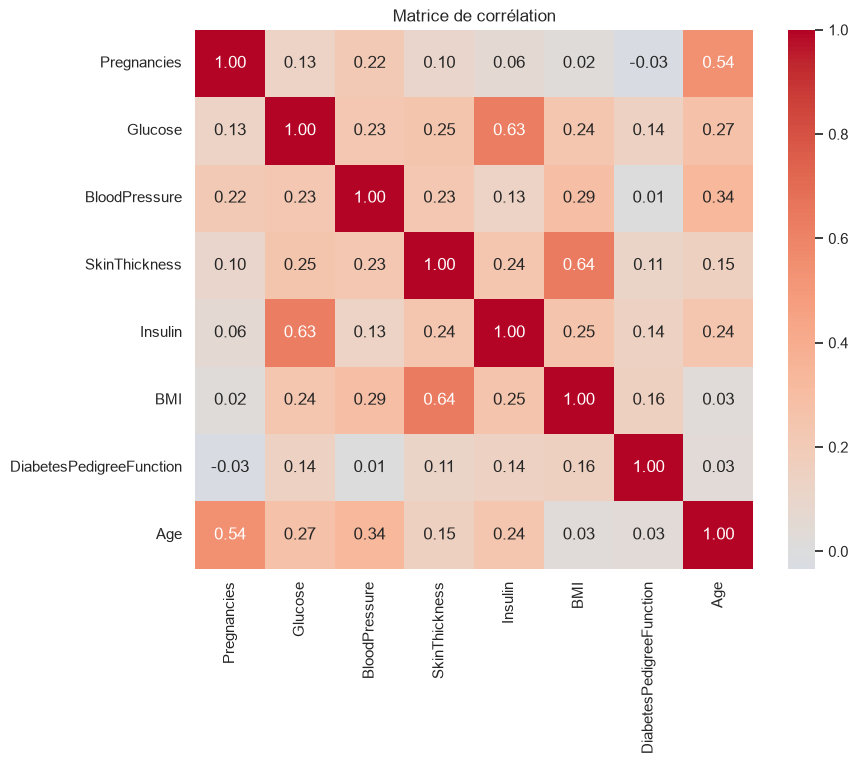

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()


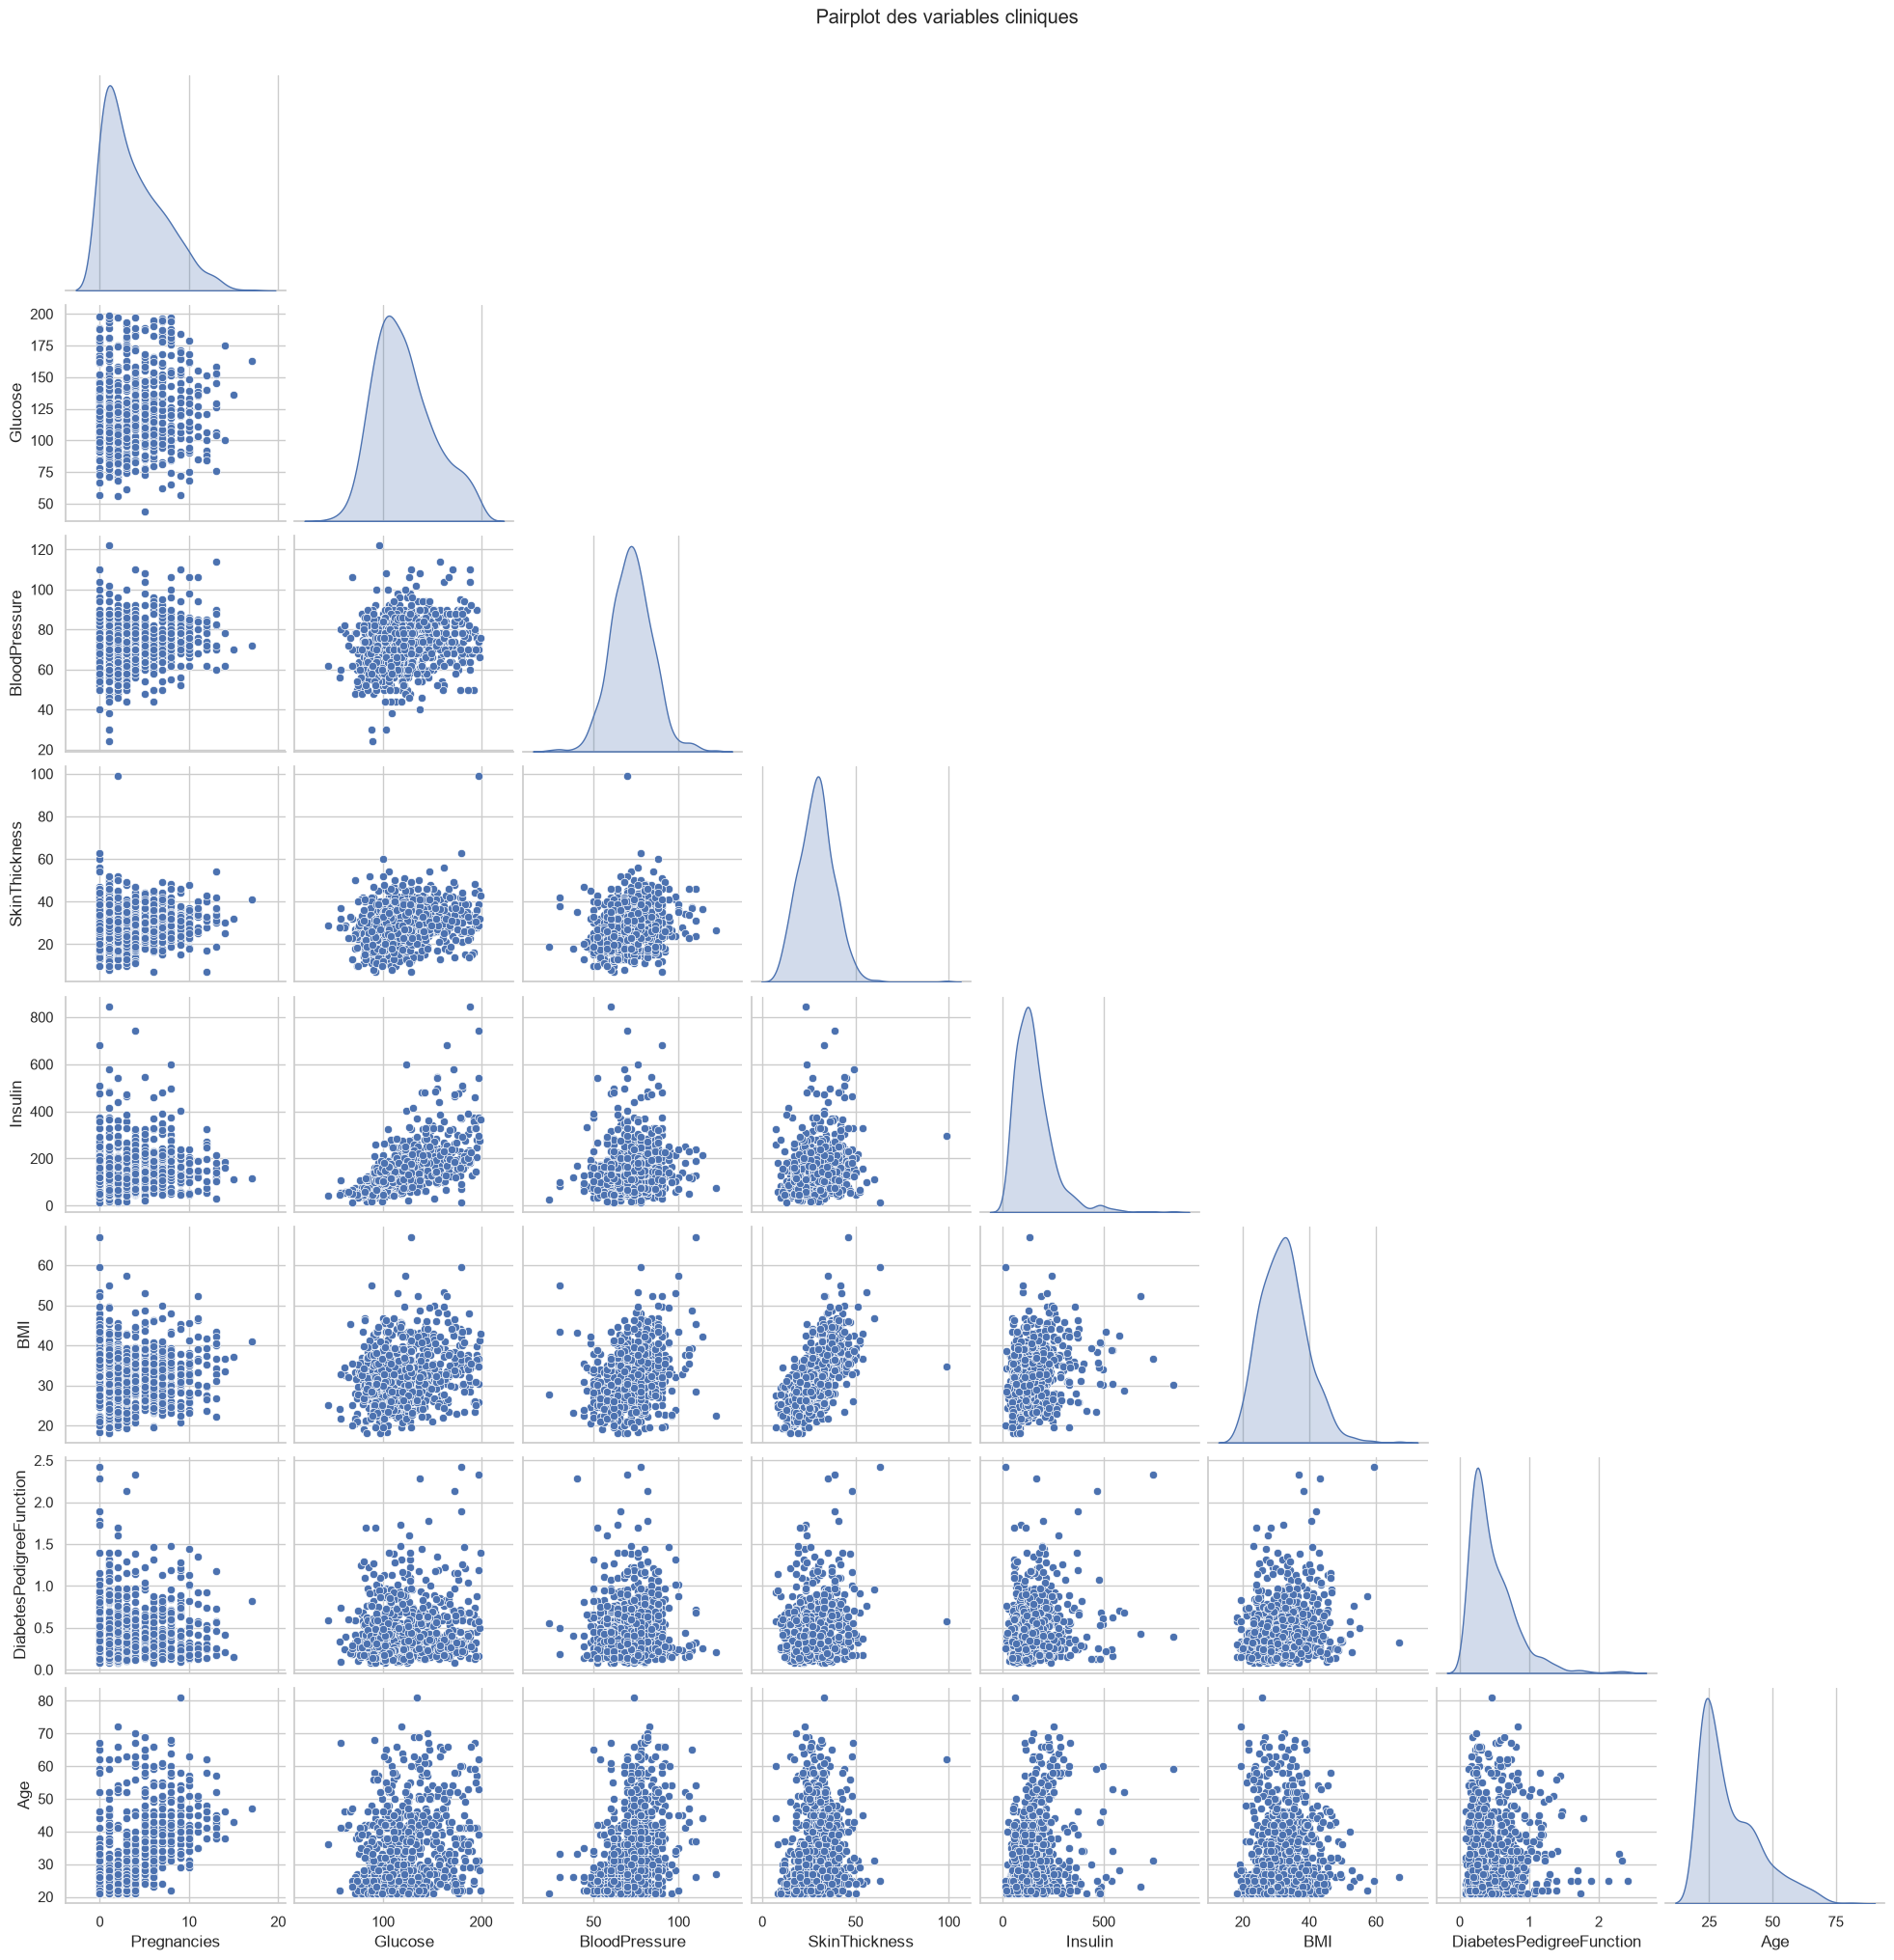

In [14]:
sns.pairplot(df_clean, diag_kind="kde", corner=True)
plt.suptitle("Pairplot des variables cliniques", y=1.02)
plt.show()


**Variables avec la plus grande variabilité / signal :** à confirmer sur le
pairplot ci-dessus, mais `Glucose`, `BMI` et `Age` se distinguent généralement
par une séparation visible des distributions — ce sont de bons candidats pour
porter le clustering (Épic SP-2).

## 8. Normalisation / standardisation

In [15]:
feature_cols = [c for c in df_clean.columns]  # toutes les variables cliniques

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean[feature_cols]), columns=feature_cols)

df_scaled.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
Pregnancies,-6.476301e-17,1.000652,-1.141852,3.906578
Glucose,2.567391e-16,1.000652,-2.546149,2.539706
BloodPressure,-5.435467e-16,1.000652,-3.966202,4.067304
SkinThickness,2.775558e-16,1.000652,-2.347330,7.422403
Insulin,-7.632783e-17,1.000652,-1.416001,7.055852
BMI,-3.932040e-16,1.000652,-2.067159,5.038967
DiabetesPedigreeFunction,2.451743e-16,1.000652,-1.189553,5.883565
Age,1.931325e-16,1.000652,-1.041549,4.063716


`StandardScaler` centre chaque variable (moyenne 0) et réduit son écart-type
à 1 — nécessaire avant K-Means, qui est sensible à l'échelle des variables
(sinon `Insulin`, à grande échelle, dominerait la distance euclidienne face à
`DiabetesPedigreeFunction`).

**Note :** le scaler est ajusté sur tout le dataset car le clustering est non supervisé
(pas de split à cette étape). Il ne sert qu'à K-Means. Les modèles de classification
(section 13) utilisent `X` non standardisé : aucun scaler n'est nécessaire pour eux.

## 9. Sauvegarde des données prétraitées

In [16]:
df_clean.to_csv(PROCESSED_DATA_PATH / "data_clean.csv", index=False)
df_scaled.to_csv(PROCESSED_DATA_PATH / "data_scaled.csv", index=False)

print("Fichiers sauvegardés dans :", PROCESSED_DATA_PATH)


Fichiers sauvegardés dans : c:\Users\Elkerymy-Mohamed\Study-DevAI\SI-PRD\data\processed


---
**Prochaine étape (Épic SP-2) :** clustering K-Means sur `data_scaled.csv`
(choix de k via elbow/silhouette, assignation des clusters, définition de
`risk_category`).

## 10. Clustering K-Means (Épic SP-2)

Objectif : regrouper les patients en profils similaires via K-Means, puis
interpréter le(s) cluster(s) pour en déduire un niveau de risque de diabète
(`risk_category`).

On travaille sur `df_scaled` (variables standardisées, section 8).

### 10.1 Choix de k — méthode du coude (elbow)

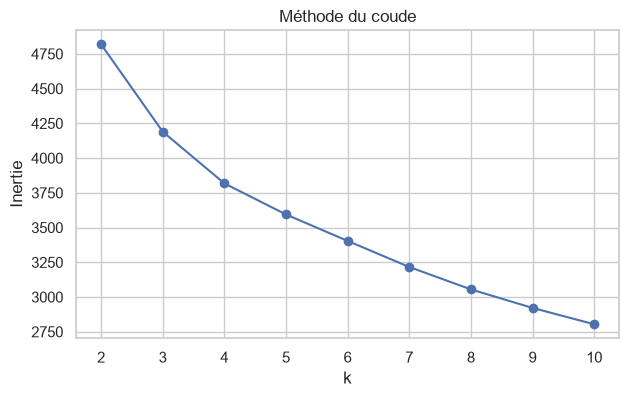

In [17]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.show()


### 10.2 Choix de k — score de silhouette

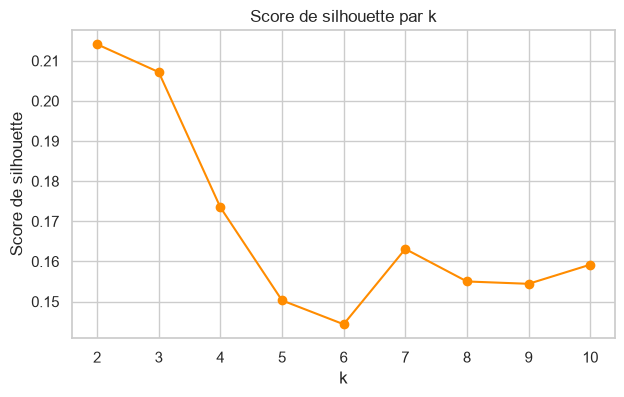

,k,silhouette_score
0,2,0.214110
1,3,0.207181
2,4,0.173495
3,5,0.150301
4,6,0.144349
5,7,0.163113
6,8,0.155013
7,9,0.154429
8,10,0.159200


In [18]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(K_range, silhouette_scores, marker='o', color='darkorange')
plt.xlabel('k')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette par k')
plt.show()

pd.DataFrame({"k": list(K_range), "silhouette_score": silhouette_scores})


**Choix retenu : k = 2.**

La courbe du coude ne présente pas de rupture nette à k=2 (la baisse d'inertie
continue au-delà), et le score de silhouette n'est pas nécessairement maximal
à k=2 non plus — ce sont des indicateurs *exploratoires*, pas une contrainte
stricte.

On retient malgré tout **k=2** car il correspond directement au besoin métier
du projet : une classification binaire du risque de diabète (`risk_category`
= faible / élevé). Un k plus élevé obligerait à regrouper arbitrairement
plusieurs clusters en seulement 2 catégories de risque, ce qui ajouterait une
étape non justifiée par les données. Le choix de k=2 est donc guidé par
l'objectif final du projet plutôt que par le seul optimum statistique.

### 10.3 Entraînement K-Means (k=2) et assignation des clusters

In [19]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(df_scaled)

score = silhouette_score(df_scaled, df_clean['Cluster'])
print(f"Score de silhouette (k=2) : {score:.3f}")

df_clean['Cluster'].value_counts().rename('n_patients')


Score de silhouette (k=2) : 0.214


Cluster
0    424
1    344
Name: n_patients, dtype: int64

### 10.4 Visualisation des clusters (projection PCA)

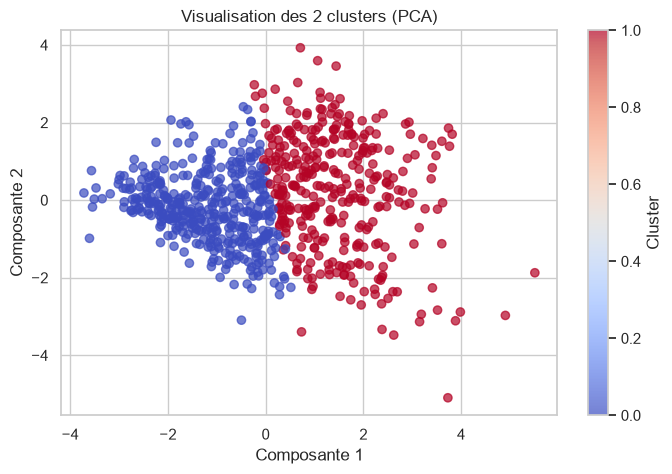

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=df_clean['Cluster'], cmap='coolwarm', alpha=0.7)
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.title('Visualisation des 2 clusters (PCA)')
plt.colorbar(label='Cluster')
plt.show()


## 11. Analyse des clusters et définition du risque (SP-16)

On calcule la moyenne de chaque variable par cluster, puis on applique les
seuils cliniques définis dans le brief pour identifier le cluster à **haut
risque** :
- Glucose > 126
- BMI > 30
- DiabetesPedigreeFunction > 0.5

Le cluster dont les moyennes dépassent ces trois seuils est étiqueté
`risque élevé`, l'autre `risque faible`.

In [21]:
cluster_means = df_clean.groupby('Cluster').mean()
cluster_means


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,2.521226,105.783491,67.254717,25.325472,107.927358,29.948160,0.428663,27.021226
1,5.476744,141.090698,78.704651,33.762209,208.693023,35.477674,0.525140,40.906977


In [22]:
def is_high_risk(row):
    return (row['Glucose'] > 126) and (row['BMI'] > 30) and (row['DiabetesPedigreeFunction'] > 0.5)

high_risk_clusters = cluster_means[cluster_means.apply(is_high_risk, axis=1)].index.tolist()

print("Cluster(s) à haut risque :", high_risk_clusters)

df_clean['risk_category'] = df_clean['Cluster'].apply(
    lambda c: 'risque élevé' if c in high_risk_clusters else 'risque faible'
)

df_clean['risk_category'].value_counts()


Cluster(s) à haut risque : [1]


risk_category
risque faible    424
risque élevé     344
Name: count, dtype: int64

**Interprétation :** le cluster à haut risque regroupe les patients avec des
niveaux de Glucose, BMI et DiabetesPedigreeFunction plus élevés que la
moyenne — cohérent avec les facteurs de risque cliniques connus du diabète
(hyperglycémie, surpoids/obésité, antécédents familiaux).

**Comment `risk_category` est attribuée :** les seuils cliniques (Glucose > 126,
BMI > 30, DPF > 0.5) sont appliqués à la **moyenne de chaque cluster**, pas à
chaque patient. Le cluster qui dépasse les trois seuils est étiqueté
« risque élevé », et tous ses patients reçoivent cette étiquette. Un patient
isolé peut donc avoir un Glucose < 126 tout en étant classé « risque élevé »,
car son cluster l'est.

## 12. Sauvegarde du dataset avec clusters et risk_category

In [23]:
df_clean.to_csv(PROCESSED_DATA_PATH / "data_clustered.csv", index=False)
print("Fichier sauvegardé :", PROCESSED_DATA_PATH / "data_clustered.csv")


Fichier sauvegardé : c:\Users\Elkerymy-Mohamed\Study-DevAI\SI-PRD\data\processed\data_clustered.csv


---
**Prochaine étape (Épic SP-3) :** classification supervisée — définir X/y à
partir de `Cluster`/`risk_category`, split train/test, gestion du
déséquilibre des classes, entraînement et comparaison de modèles.

## 13. Classification supervisée (Épic SP-3)

On entraîne maintenant des modèles supervisés pour prédire `risk_category`
à partir des variables cliniques. Les features utilisées en entrée (`X`)
sont les mêmes que celles qu'un praticien saisira dans l'application
(Glucose, BMI, DiabetesPedigreeFunction, etc.) — c'est pour cela qu'on les
garde dans `X` malgré le fait qu'elles aient aussi servi à définir
`risk_category` via les seuils cliniques (section 11). Le modèle doit
généraliser cette règle de risque à de nouveaux patients, sans qu'on ait
besoin de relancer un clustering à chaque nouvelle prédiction.

### 13.1 Définition de X / y et split train/test

In [24]:
from sklearn.model_selection import train_test_split

# Cluster et risk_category sont retirés de X : ce sont les sorties du
# clustering (section 10-11), pas des variables d'entrée cliniques.
# risk_category devient la cible (y) à prédire.
X = df_clean.drop(columns=['Cluster', 'risk_category'])
y = df_clean['risk_category']

# stratify=y conserve la même proportion de chaque classe dans train et test
# (important avec un dataset de taille modeste comme ici).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensions du jeu d'entraînement :", X_train.shape)
print("Dimensions du jeu de test :", X_test.shape)
print("Dimensions du jeu d'entraînement (cible) :", y_train.shape)
print("Dimensions du jeu de test (cible) :", y_test.shape)


Dimensions du jeu d'entraînement : (614, 8)
Dimensions du jeu de test : (154, 8)
Dimensions du jeu d'entraînement (cible) : (614,)
Dimensions du jeu de test (cible) : (154,)


### 13.2 Gestion du déséquilibre des classes (SMOTE)

On vérifie et corrige un éventuel déséquilibre entre les deux classes dans
le jeu d'entraînement uniquement — **jamais sur le jeu de test**, pour ne
pas fausser l'évaluation avec des exemples synthétiques.

`SMOTE` (Synthetic Minority Over-sampling TEchnique) génère de nouveaux
exemples synthétiques de la classe minoritaire par interpolation entre
exemples existants, plutôt que de simplement dupliquer des lignes.

In [25]:
from imblearn.over_sampling import SMOTE

# Déséquilibre AVANT rééchantillonnage
print("Avant SMOTE :", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Les deux classes sont maintenant équilibrées dans le train set
print("Après SMOTE :", y_train_resampled.value_counts().to_dict())


Avant SMOTE : {'risque faible': 339, 'risque élevé': 275}
Après SMOTE : {'risque faible': 339, 'risque élevé': 339}


### 13.3 Entraînement et comparaison de 3 modèles (SP-19)

On entraîne 3 modèles sur le **même** jeu d'entraînement rééquilibré
(`X_train_resampled` / `y_train_resampled`) et on les évalue tous sur le
**même** jeu de test original, non modifié (`X_test` / `y_test`), pour une
comparaison équitable.

Pour chaque modèle :
- **precision / recall / f1-score** par classe
- **matrice de confusion** (diagonale = prédictions correctes)

⚠️ Note d'interprétation : un score très élevé (proche de 1.0) pour la
régression logistique est attendu ici. `risk_category` vient du **clustering
K-Means (k=2)** : les seuils cliniques (section 11) servent seulement à choisir
quel cluster est « risque élevé ». Or la frontière entre 2 clusters K-Means est
linéaire, donc la régression logistique la retrouve presque parfaitement. Ce
n'est pas une erreur de code, mais un biais structurel du design
(clustering → label → classification sur les mêmes variables). Le score de la
régression logistique ne mesure donc pas une vraie capacité à prédire le diabète ;
on retient le **Random Forest** comme modèle de référence pour le tuning (SP-20).

Résultats pour Logistic Regression :
               precision    recall  f1-score   support

risque faible       1.00      1.00      1.00        85
 risque élevé       1.00      1.00      1.00        69

     accuracy                           1.00       154
    macro avg       1.00      1.00      1.00       154
 weighted avg       1.00      1.00      1.00       154



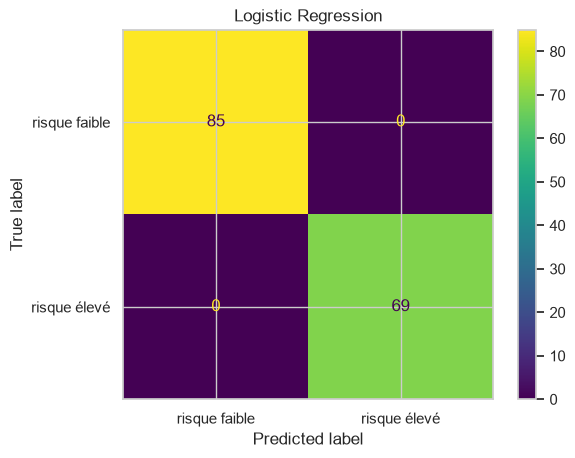

Résultats pour Decision Tree :
               precision    recall  f1-score   support

risque faible       0.83      0.88      0.86        85
 risque élevé       0.84      0.78      0.81        69

     accuracy                           0.84       154
    macro avg       0.84      0.83      0.83       154
 weighted avg       0.84      0.84      0.84       154



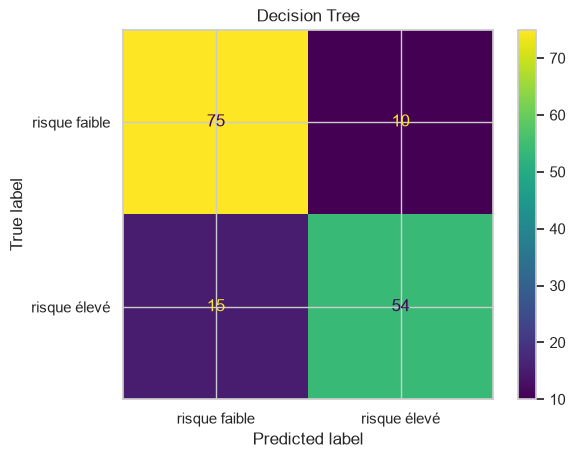

Résultats pour Random Forest :
               precision    recall  f1-score   support

risque faible       0.90      0.99      0.94        85
 risque élevé       0.98      0.87      0.92        69

     accuracy                           0.94       154
    macro avg       0.94      0.93      0.93       154
 weighted avg       0.94      0.94      0.93       154



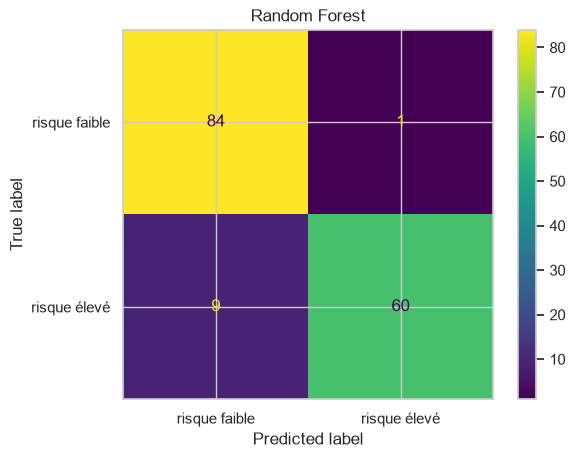

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}

for model_name, model in models.items():
    # Entraînement sur le train set rééquilibré (SMOTE)
    model.fit(X_train_resampled, y_train_resampled)

    # Évaluation sur le test set original (non rééchantillonné)
    Y_pred = model.predict(X_test)

    print(f"Résultats pour {model_name} :")
    print(classification_report(y_test, Y_pred))

    # Matrice de confusion : lignes = vraie classe, colonnes = classe prédite
    cm = confusion_matrix(y_test, Y_pred, labels=model.classes_)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()
    plt.title(model_name)
    plt.show()

    # On garde les résultats pour comparaison / tuning ultérieur (SP-20)
    results[model_name] = {
        'classification_report': classification_report(y_test, Y_pred, output_dict=True),
        'confusion_matrix': cm
    }

### 13.4 Sauvegarde du modèle de référence (avant tuning)

On sauvegarde le Random Forest de la section 13.3 (paramètres par défaut) et
l'ordre des 8 variables d'entrée (`feature_columns`). Ce modèle sert de
**référence** pour mesurer l'apport du tuning.

In [27]:
import joblib , os 


os.makedirs(ROOT_PATH / "models", exist_ok=True)
joblib.dump(models['Random Forest'] , ROOT_PATH / "models" / "random_forest_model.joblib")
joblib.dump(list(X_train.columns), ROOT_PATH / "models" / "feature_columns.joblib")

['c:\\Users\\Elkerymy-Mohamed\\Study-DevAI\\SI-PRD\\models\\feature_columns.joblib']

### 13.5 Tuning des hyperparamètres du Random Forest (SP-20)

On cherche les meilleurs hyperparamètres du Random Forest avec `GridSearchCV`
(validation croisée stratifiée à 5 plis). Choix importants :
- **SMOTE est dans le pipeline** : à chaque pli, il n'est appliqué que sur la
  partie entraînement du pli. Les points synthétiques n'entrent jamais dans la
  validation, donc pas de fuite de données.
- On entraîne sur `X_train` / `y_train` (jeu **d'origine**), pas sur `X_train_resampled`.
- Métrique : **F1-score de la classe « risque élevé »**, car c'est la classe
  qu'il ne faut pas rater.

In [28]:
from sklearn.model_selection import GridSearchCV , StratifiedKFold
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

pipeline_RandomForest = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [300 , 350 , 400],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_leaf': [1, 2, 4],
}

f1_risque_eleve = make_scorer(f1_score, pos_label='risque élevé')

grid_search = GridSearchCV(
    estimator=pipeline_RandomForest,
    param_grid=param_grid,
    scoring=f1_risque_eleve,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score F1 :", grid_search.best_score_)

Y_pred_best = grid_search.predict(X_test)
print("Classification report pour le meilleur modèle :")
print(classification_report(y_test, Y_pred_best))

Meilleurs hyperparamètres : {'rf__max_depth': None, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 350}
Meilleur score F1 : 0.950242889644145
Classification report pour le meilleur modèle :
               precision    recall  f1-score   support

risque faible       0.90      0.99      0.94        85
 risque élevé       0.98      0.87      0.92        69

     accuracy                           0.94       154
    macro avg       0.94      0.93      0.93       154
 weighted avg       0.94      0.94      0.93       154



**Résultat du tuning :** meilleurs paramètres `n_estimators=350`,
`max_depth=None`, `min_samples_leaf=2`, F1 en validation croisée ≈ 0.95.
Sur le jeu de test : F1 « risque élevé » = 0.92, accuracy = 0.94, soit les
mêmes scores que le Random Forest par défaut. Le score a atteint un plateau :
le tuning n'apporte pas de gain sur ce dataset de taille modeste, et un
deuxième essai de grille (300-400 arbres) n'a rien changé.

### 13.6 Sauvegarde du Random Forest tuned

On extrait le Random Forest du pipeline de tuning (sans l'étape SMOTE, qui ne
sert qu'à l'entraînement) et on le sauvegarde. Ainsi, le charger ne nécessite
pas `imbalanced-learn`.

In [29]:
# On sauvegarde uniquement le Random Forest (sans l'étape SMOTE, inutile à la prédiction)
best_rf = grid_search.best_estimator_.named_steps['rf']
joblib.dump(best_rf, ROOT_PATH / "models" / "random_forest_tuned.joblib")

['c:\\Users\\Elkerymy-Mohamed\\Study-DevAI\\SI-PRD\\models\\random_forest_tuned.joblib']

### 13.7 Pipelines finaux et bundle (SP-21)

On assemble **deux pipelines** déjà entraînés (aucun nouvel entraînement, donc
mêmes résultats) :
- `pipeline_risque` : imputer → Random Forest tuned. Prédit **risque élevé / faible**.
- `pipeline_cluster` : imputer → scaler → K-Means. Prédit le **cluster** (0 ou 1).

Ils ne sont pas fusionnés en un seul pipeline : le Random Forest a été entraîné
sur les valeurs **non standardisées**, alors que K-Means a besoin des valeurs
standardisées.

Le **bundle** (`bundle.joblib`) regroupe tout ce dont l'application a besoin :
`pipeline_risque`, `pipeline_cluster`, `features` (ordre des 8 variables),
`zero_as_missing` (colonnes où 0 signifie « valeur manquante ») et
`high_risk_clusters` (cluster(s) étiqueté(s) « risque élevé »).

Les deux dernières lignes vérifient que les pipelines redonnent exactement les
mêmes prédictions qu'avant (`True` attendu).

In [30]:
import warnings
# Avertissement sans conséquence : le pipeline reçoit un DataFrame, l'imputer renvoie un tableau numpy
warnings.filterwarnings("ignore", message="X does not have valid feature names")

pipeline_risque = Pipeline([
    ('imputer', imputer_uniform),
    ('rf', best_rf)
])

pipeline_cluster = Pipeline([
    ('imputer', imputer_uniform),
    ('scaler', scaler),
    ('kmeans', kmeans)
])

bundle = {
    'pipeline_risque': pipeline_risque,
    'pipeline_cluster': pipeline_cluster,
    'features': list(X_train.columns),
    'zero_as_missing': nan_columns,
    'high_risk_clusters': high_risk_clusters,
}
joblib.dump(bundle, ROOT_PATH / "models" / "bundle.joblib")

# Vérification : mêmes résultats qu'avant le bundle
print((pipeline_risque.predict(X_test) == Y_pred_best).all())
print((pipeline_cluster.predict(X) == df_clean['Cluster']).all())

True
True


In [31]:
import mlflow 

mlflow.set_tracking_uri("http://127.0.0.1:5000")  # Remplacez par l'URI de votre serveur MLflow
mlflow.set_experiment("Diabetes Risk Prediction")


2026/10/05 18:54:26 INFO mlflow.tracking.fluent: Experiment with name 'Diabetes Risk Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/Elkerymy-Mohamed/Study-DevAI/SI-PRD/mlartifacts/2', creation_time=1791226466890, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1791226466890, lifecycle_stage='active', name='Diabetes Risk Prediction', tags={}, trace_location=None, workspace='default'>

In [33]:
with mlflow.start_run(run_name="kmeans_clustering"):
    mlflow.log_params({"n_clusters": 2, "init": "k-means++", "random_state": 42})
    mlflow.log_metric("silhouette", silhouette_score(df_scaled, kmeans.labels_))
    mlflow.log_metric("inertia", kmeans.inertia_)
    mlflow.sklearn.log_model(kmeans, "kmeans_model")

2026/10/05 19:01:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/05 19:02:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run kmeans_clustering at: http://127.0.0.1:5000/#/experiments/2/runs/6864285eea2c4730824d935219dbf1c6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [40]:
for name , res in results.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_params(models[name].get_params())
        mlflow.log_metric('accuracy', res['classification_report']['accuracy'])
        mlflow.log_metric('f1_risque_eleve', res['classification_report']['risque élevé']['f1-score'])
        mlflow.log_metric('recall_risque_eleve', res['classification_report']['risque élevé']['recall'])
        mlflow.sklearn.log_model(models[name], f"{name.replace(' ', '_').lower()}_model" , skops_trusted_types=["sklearn.tree._tree.Tree"])
rep = classification_report(y_test, Y_pred_best, output_dict=True)
with mlflow.start_run(run_name="random_forest_tuned"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric('best_f1_score', grid_search.best_score_)
    mlflow.log_metric('accuracy', rep['accuracy'])
    mlflow.log_metric('f1_risque_eleve', rep['risque élevé']['f1-score'])
    mlflow.log_metric('recall_risque_eleve', rep['risque élevé']['recall'])
    mlflow.sklearn.log_model(best_rf, "random_forest_tuned_model", skops_trusted_types=["sklearn.tree._tree.Tree"])


2026/10/05 19:43:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/05 19:43:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/10/05 19:43:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/2/runs/5533b2c1c48b49b3886133c2487882ec
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


2026/10/05 19:43:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/10/05 19:43:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Decision Tree at: http://127.0.0.1:5000/#/experiments/2/runs/f8e738b613bf42359743ad4568e49a7c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


2026/10/05 19:43:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/2/runs/a3c899f96d8a4ff48ab4fd1936b73855
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


2026/10/05 19:43:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/05 19:43:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run random_forest_tuned at: http://127.0.0.1:5000/#/experiments/2/runs/4b0794b7c3114b02a63048132db7eddd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [41]:
import sklearn
exp = mlflow.get_experiment_by_name("Diabetes Risk Prediction")
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="tags.mlflow.runName = 'random_forest_tuned'",
    order_by=["start_time DESC"],
)
run_id = runs.iloc[0]['run_id']

with mlflow.start_run(run_id=run_id):
    mlflow.log_params({
        'feature_cols': ', '.join(list(X_train.columns)),
        'dataset' : 'data_clean.csv',
        'train_rows' : X_train.shape[0],
        'test_rows' : X_test.shape[0],
        'sklearn_version' : sklearn.__version__,
        'pandas_version' : pd.__version__,
        'mlflow_version' : mlflow.__version__,
    })
    

🏃 View run random_forest_tuned at: http://127.0.0.1:5000/#/experiments/2/runs/4b0794b7c3114b02a63048132db7eddd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [43]:
result = mlflow.register_model(f"runs:/{run_id}/random_forest_tuned_model", "diabetes_risk_random_forest")
client = mlflow.tracking.MlflowClient()
client.set_registered_model_alias('diabetes_risk_random_forest', 'version', result.version)

Registered model 'diabetes_risk_random_forest' already exists. Creating a new version of this model...
2026/10/05 20:07:48 WARNING mlflow.tracking._model_registry.fluent: Run with id 4b0794b7c3114b02a63048132db7eddd has no artifacts at artifact path 'random_forest_tuned_model', registering model based on models:/m-a798f59c2fa84313a16c7c2f427ce6ee instead
2026/10/05 20:07:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: diabetes_risk_random_forest, version 2
Created version '2' of model 'diabetes_risk_random_forest'.
